# R1 — Análisis exploratorio sobre train

Se ejecuta **después de R0** (necesita el split y el contrato de features) y
**antes de R2**


Todas las salidas se guardan en `06_results/eda/` y las figuras en
`07_figures/`.

In [ ]:

import sys, os

AQUI = os.getcwd()                    # los notebooks y vishing_common.py conviven
if AQUI not in sys.path:
    sys.path.insert(0, AQUI)

import numpy as np
import pandas as pd
import vishing_common as vc

vc.set_all_seeds()                    # random, numpy y torch (+ cuDNN determinista)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

print("dataset:", vc.RAW_FILENAME, "(esquema", vc.DATASET_VERSION + ")")
print("bucket :", vc.BUCKET, "| prefijo:", vc.PREFIX)
print("seed   :", vc.SEED, "| split:", vc.SPLIT_MODE, "| política:", vc.FEATURE_POLICY)
print("xgboost se ejecutará en:", vc.xgb_device())
vc.check_versions()

dataset: biocatch_sinthetic_data_v3.csv (esquema v3)
bucket : poc-vishing | prefijo: v2
seed   : 42 | split: grouped | política: audited
xgboost se ejecutará en: cuda
  versiones OK: numpy 2.0.2, pandas 2.2.3, scipy 1.14.1, sklearn 1.5.2, imblearn 0.12.4, xgboost 2.1.4


,paquete,instalada,esperado,ok
0,numpy,2.0.2,">=1.26,<2.1",True
1,pandas,2.2.3,">=2.1,<2.3",True
2,scipy,1.14.1,">=1.11,<1.15",True
3,sklearn,1.5.2,">=1.4,<1.6",True
4,imblearn,0.12.4,">=0.12,<0.13",True
5,xgboost,2.1.4,">=2.0,<2.2",True


In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

train = vc.read_parquet(vc.P.train)
cfg = vc.read_json(vc.P.feature_contract)
contract = cfg["contratos"][cfg["activo"]]
FEATS = contract["features"]

print("train:", train.shape, "| features del contrato:", len(FEATS))
print("política:", contract["policy"])
if contract["removed"]:
    print("excluidas por la auditoría de R0:")
    for f, m in contract["removed"].items():
        print("   - %-30s %s" % (f, m))
else:
    print("la auditoría de R0 no excluyó ninguna variable (esperado en el v3)")

train: (60134, 60) | features del contrato: 44
política: audited
la auditoría de R0 no excluyó ninguna variable (esperado en el v3)


## 1. Integridad

In [3]:
print("nulos totales      :", int(train[FEATS].isna().sum().sum()))
print("filas duplicadas   :", int(train.duplicated(subset=FEATS).sum()))
print("row_id duplicados  :", int(train[vc.ROW_ID].duplicated().sum()))
print("clientes únicos    :", train[vc.GROUP_COL].nunique())
print("sesiones por cliente: %.2f" % (len(train) / train[vc.GROUP_COL].nunique()))
if "session_timestamp" in train:
    ts = pd.to_datetime(train.session_timestamp)
    print("rango temporal     : %s -> %s" % (ts.min().date(), ts.max().date()))

n1 = int(train[vc.TARGET].sum())
print()
print("legítimas: %d (%.2f%%)" % (len(train) - n1, 100 * (1 - train[vc.TARGET].mean())))
print("vishing  : %d (%.2f%%)" % (n1, 100 * train[vc.TARGET].mean()))

nulos totales      : 0
filas duplicadas   : 0
row_id duplicados  : 0
clientes únicos    : 22800
sesiones por cliente: 2.64
rango temporal     : 2025-01-01 -> 2025-12-31

legítimas: 57125 (95.00%)
vishing  : 3009 (5.00%)


## 2. Separabilidad univariada

Cuatro instrumentos por variable: U de Mann-Whitney (¿difieren las
distribuciones?), d de Cohen (¿cuánto?), correlación biserial puntual
(asociación con el objetivo) y AUC univariada (poder discriminante de la
variable por sí sola).

In [4]:
sep = vc.separability_table(train, FEATS)
display(sep.head(20))

print()
print("=== reparto de tamaños de efecto ===")
print(sep.efecto.value_counts().to_string())
print()
print("significativas con p < 0.001: %d de %d"
      % (int((sep.p_mannwhitney < 0.001).sum()), len(sep)))
print()
# Debe coincidir con TECHO_AUC_UNIVARIADO del generador. Si regeneras el
# dataset con otro techo, cámbialo aquí también: es la única cifra de este
# notebook que depende de la calibración del generador.
TECHO_AUC = 0.85
REF_MAX_GENERADOR = 0.8380      # máximo medido sobre el dataset completo (v3.1)

print("=== techo de separabilidad univariada ===")
print("techo declarado: %.2f" % TECHO_AUC)
print("AUC máxima: %.4f (%s)" % (sep.auc_dir.max(), sep.feature.iloc[0]))
print("features por encima de 0.80: %d" % int((sep.auc_dir > 0.80).sum()))
print("features por encima del techo: %d" % int((sep.auc_dir > TECHO_AUC).sum()))
print("referencia del generador (dataset completo): máx. %.4f, 0 por encima"
      % REF_MAX_GENERADOR)
print("del techo.")
if (sep.auc_dir > TECHO_AUC).any():
    print()
    print("AVISO: hay variables por encima del techo de %.2f. No debería" % TECHO_AUC)
    print("ocurrir. Revisar que el CSV cargado sea el correcto y que TECHO_AUC")
    print("coincida con el del generador, antes de interpretar cualquier")
    print("resultado de modelado.")
    print(sep[sep.auc_dir > TECHO_AUC][["feature", "auc_dir"]].to_string(index=False))
vc.write_csv(sep, vc.P.eda_separability)

,feature,auc,auc_dir,cohens_d,efecto,p_mannwhitney,r_biserial,mediana_legitima,mediana_vishing,degenerada
0,max_hesitation_duration_s,0.8399,0.8399,2.0075,grande,0.0,0.4010,1.8200,6.680000e+00,False
1,data_familiarity_score,0.1708,0.8292,-1.5084,grande,0.0,-0.3124,0.8194,6.178000e-01,False
2,segmented_typing_ratio,0.8150,0.8150,1.5931,grande,0.0,0.3281,0.0764,2.450000e-01,False
3,swipe_directional_variance,0.8122,0.8122,1.4411,grande,0.0,0.2997,0.1807,3.687000e-01,False
4,hesitation_count,0.7978,0.7978,1.6274,grande,0.0,0.3344,1.0000,3.000000e+00,False
5,transaction_amount_cop,0.7920,0.7920,1.7286,grande,0.0,0.3527,71706.0000,1.214254e+06,False
6,session_duration_s,0.7874,0.7874,1.5616,grande,0.0,0.3223,151.3000,3.086600e+02,False
7,call_overlap_duration_s,0.7860,0.7860,3.1131,grande,0.0,0.5616,0.0000,1.125000e+02,False
8,dead_time_periods,0.7845,0.7845,1.6037,grande,0.0,0.3301,1.0000,2.000000e+00,False
9,input_error_count,0.7831,0.7831,1.5956,grande,0.0,0.3286,1.0000,2.000000e+00,False



=== reparto de tamaños de efecto ===
efecto
grande          30
pequeño          7
medio            5
despreciable     2

significativas con p < 0.001: 43 de 44

=== techo de separabilidad univariada ===
techo declarado: 0.85
AUC máxima: 0.8399 (max_hesitation_duration_s)
features por encima de 0.80: 4
features por encima del techo: 0
referencia del generador (dataset completo): máx. 0.8380, 0 por encima
del techo.
  escrito s3://poc-vishing/v2/06_results/eda/separability.csv  (44 filas)


's3://poc-vishing/v2/06_results/eda/separability.csv'

  figura -> s3://poc-vishing/v2/07_figures/fig02_auc_univariada.png


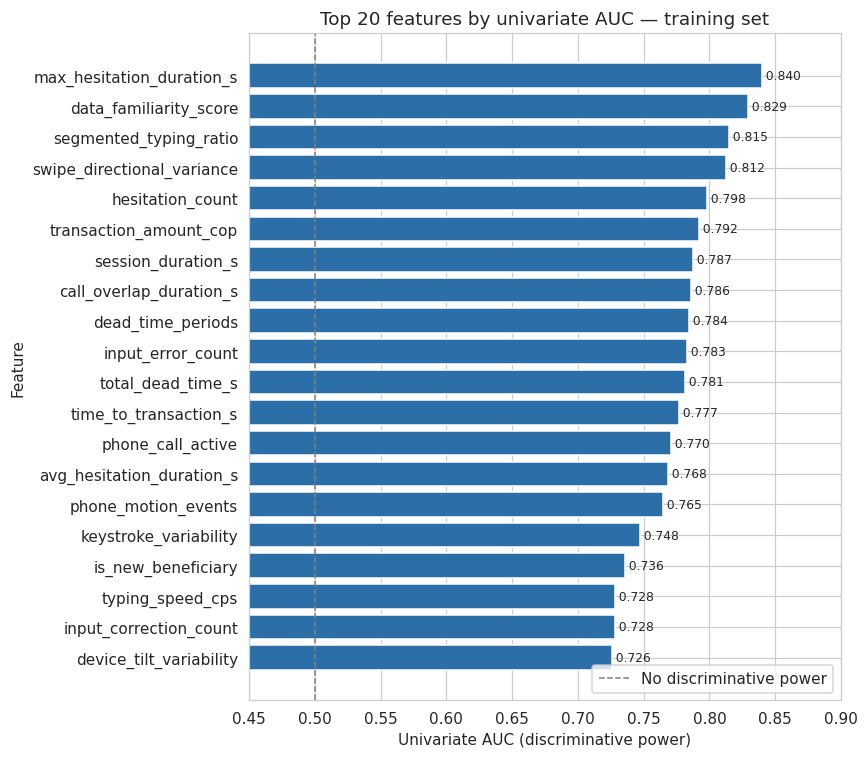

In [5]:
top = sep.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
colores = ["#c0392b" if a >= TECHO_AUC else "#2c6fa8" for a in top.auc_dir]
ax.barh(top.feature, top.auc_dir, color=colores)
ax.axvline(0.5, ls="--", c="gray", lw=1, label="No discriminative power")
ax.set_xlim(0.45, max(0.9, float(top.auc_dir.max()) + 0.05))
ax.set_xlabel("Univariate AUC (discriminative power)")
ax.set_ylabel("Feature")
ax.set_title("Top 20 features by univariate AUC — training set")
for i, v in enumerate(top.auc_dir):
    ax.text(v, i, " %.3f" % v, va="center", fontsize=8)
ax.legend(loc="lower right")
plt.tight_layout()
vc.save_figure(fig, vc.P.figure("fig02_auc_univariada.png"))
plt.show()

## 3. Variables binarias: chi cuadrado y razón de momios

In [6]:
binarias = vc.binary_association_table(train, FEATS)
display(binarias)

print()
print("Comparar con lo que reporta el manuscrito, calculado sobre otra base")
print("(50.000 sesiones de otra generación, incluyendo escritorio y evaluación):")
print("   remote_access_tool_detected OR=2.57 | suspicious_app_detected OR=2.05")
print("   phone_call_active OR=2.01           | is_new_beneficiary OR=1.76")
print()
print("Sobre el v3 estas cifras cambian por diseño, no por ruido: la prevalencia")
print("de phone_call_active en vishing pasó del 85 % literal del diccionario")
print("original al 60,4 %, porque ahora la variable significa 'llamada detectada")
print("en el mismo dispositivo'. Con el 85 % esa sola binaria daba AUC 0,90 y")
print("el problema se volvía trivial; con la reinterpretación queda en 0,77,")
print("por debajo del techo. El paper debe citar los valores de aquí y")
print("explicar el cambio de definición.")
vc.write_csv(binarias, vc.P.eda_binaries)

,feature,odds_ratio,or_ic95_lo,or_ic95_hi,chi2,p,significativa_999,tasa_si_1,tasa_si_0,haldane
0,remote_access_tool_detected,37.6674,31.3968,45.1905,3856.95,0.000000e+00,True,0.6388,0.0448,False
1,phone_call_active,23.6365,21.8032,25.6239,10531.10,0.000000e+00,True,0.3460,0.0219,False
2,suspicious_app_detected,12.9355,10.8947,15.3585,1394.48,3.319216e-305,True,0.3882,0.0468,False
3,is_new_beneficiary,10.9984,10.1835,11.8784,5362.88,0.000000e+00,True,0.2136,0.0241,False
4,transaction_attempted,3.3574,3.0440,3.7030,654.16,2.785831e-144,True,0.0680,0.0213,False
5,is_atypical_hour,1.8755,1.7126,2.0540,188.63,6.336609e-43,True,0.0818,0.0453,False



Comparar con lo que reporta el manuscrito, calculado sobre otra base
(50.000 sesiones de otra generación, incluyendo escritorio y evaluación):
   remote_access_tool_detected OR=2.57 | suspicious_app_detected OR=2.05
   phone_call_active OR=2.01           | is_new_beneficiary OR=1.76

Sobre el v3 estas cifras cambian por diseño, no por ruido: la prevalencia
de phone_call_active en vishing pasó del 85 % literal del diccionario
original al 60,4 %, porque ahora la variable significa 'llamada detectada
en el mismo dispositivo'. Con el 85 % esa sola binaria daba AUC 0,90 y
el problema se volvía trivial; con la reinterpretación queda en 0,77,
por debajo del techo. El paper debe citar los valores de aquí y
explicar el cambio de definición.
  escrito s3://poc-vishing/v2/06_results/eda/binary_odds_ratios.csv  (6 filas)


's3://poc-vishing/v2/06_results/eda/binary_odds_ratios.csv'

## 4. Distribuciones por clase

  figura -> s3://poc-vishing/v2/07_figures/fig03_distribuciones_clase.png


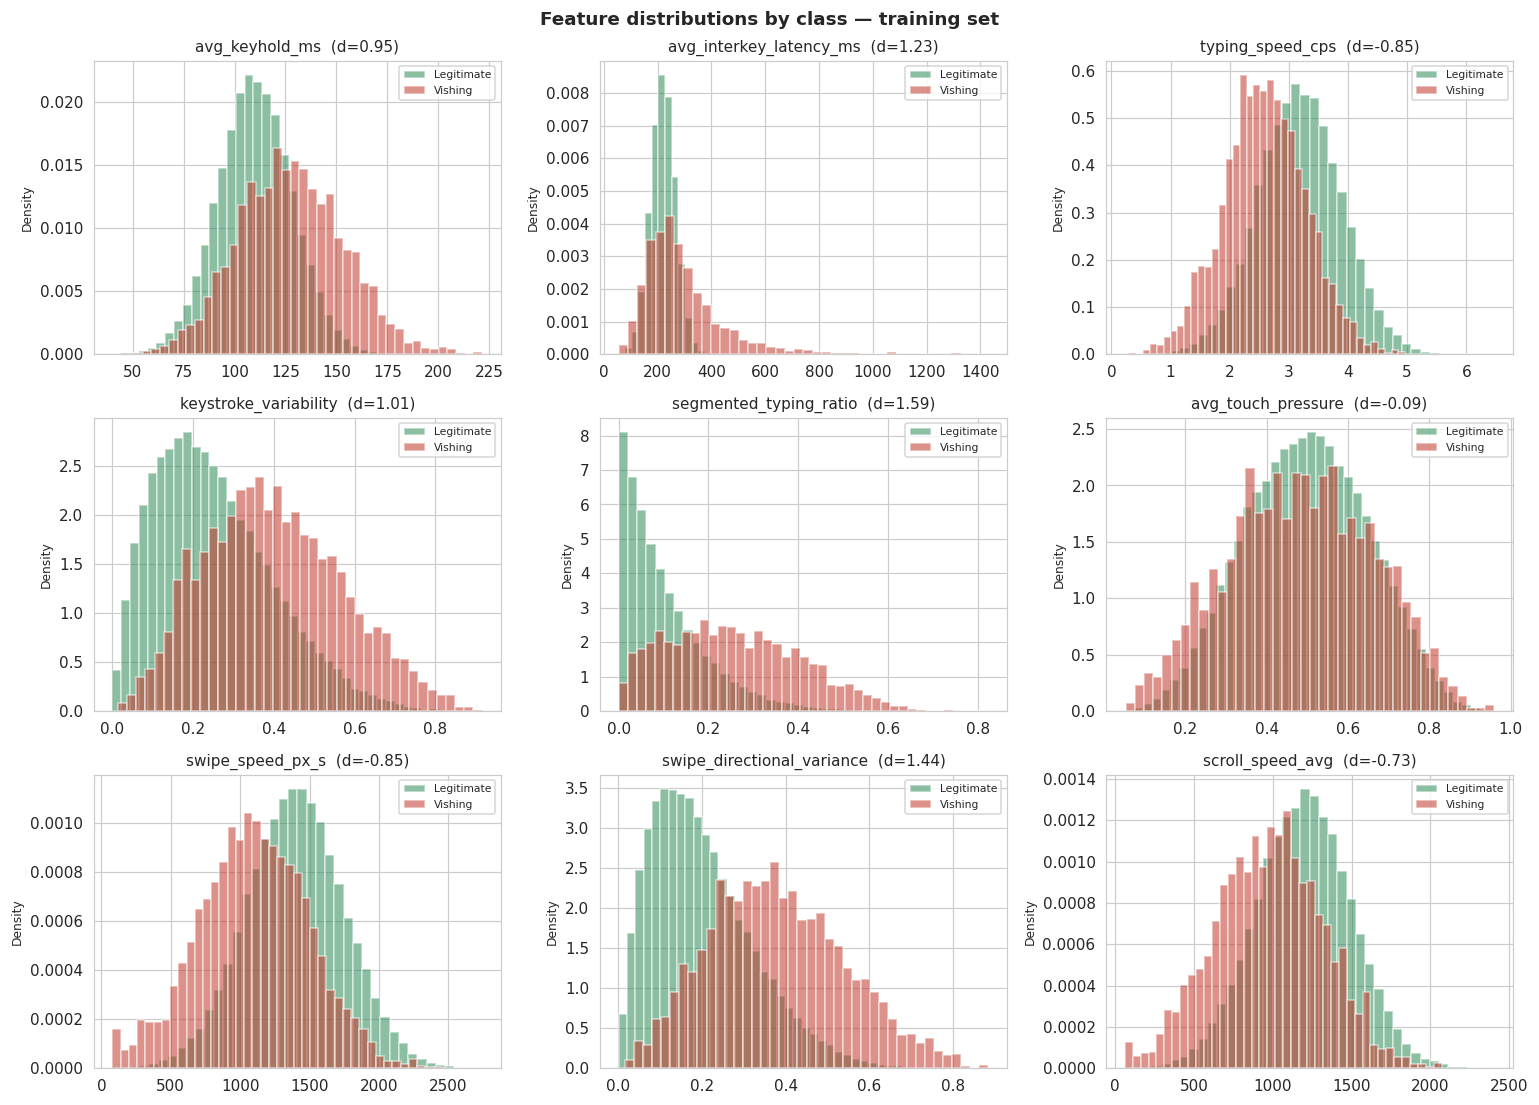

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN — edita esta lista
# ─────────────────────────────────────────────────────────────────────────
# Variables a graficar, una por panel, en este orden. Lista vacía => las N
# primeras por AUC univariada (comportamiento por defecto de la versión previa).
VARS_DISTRIBUCIONES = [
    'avg_keyhold_ms', 'avg_interkey_latency_ms', 'typing_speed_cps',
    'keystroke_variability', 'segmented_typing_ratio', 'avg_touch_pressure',
    'swipe_speed_px_s', 'swipe_directional_variance', "scroll_speed_avg"
]
N_POR_DEFECTO = 9          
N_COLUMNAS = 3           
BINS = 40
# ─────────────────────────────────────────────────────────────────────────

if VARS_DISTRIBUCIONES:
    faltan = [f for f in VARS_DISTRIBUCIONES if f not in train.columns]
    assert not faltan, "variables inexistentes en train: %s" % faltan
    fuera = [f for f in VARS_DISTRIBUCIONES if f not in FEATS]
    if fuera:
        print("AVISO: fuera del contrato de features (se grafican igual):", fuera)
    continuas = list(VARS_DISTRIBUCIONES)
else:
    continuas = [f for f in sep[~sep.degenerada].feature
                 if train[f].nunique() > 10][:N_POR_DEFECTO]
    print("lista vacía -> por defecto, top %d por AUC univariada" % N_POR_DEFECTO)

n_filas = int(np.ceil(len(continuas) / N_COLUMNAS))
fig, axes = plt.subplots(n_filas, N_COLUMNAS,
                         figsize=(4.7 * N_COLUMNAS, 3.4 * n_filas),
                         squeeze=False)
for ax, f in zip(axes.ravel(), continuas):
    for v, c, lab in [(0, "#2e8b57", "Legitimate"), (1, "#c0392b", "Vishing")]:
        ax.hist(train.loc[train[vc.TARGET] == v, f], bins=BINS, alpha=0.55,
                density=True, color=c, label=lab)
    fila = sep.loc[sep.feature == f, "cohens_d"]
    titulo = "%s  (d=%.2f)" % (f, float(fila.iloc[0])) if len(fila) else f
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7)
for ax in axes.ravel()[len(continuas):]:
    ax.axis("off")
fig.suptitle("Feature distributions by class — training set", fontweight="bold")
plt.tight_layout()
vc.save_figure(fig, vc.P.figure("fig03_distribuciones_clase.png"))
plt.show()

## 5. Correlaciones

pares con |r| >= 0.70: 4


,feature_a,feature_b,r_abs
0,dead_time_periods,total_dead_time_s,0.8534
1,input_error_count,input_correction_count,0.7371
2,avg_hesitation_duration_s,max_hesitation_duration_s,0.7360
3,total_dead_time_s,dead_time_ratio,0.7128


  escrito s3://poc-vishing/v2/06_results/eda/correlations.csv  (4 filas)
  figura -> s3://poc-vishing/v2/07_figures/fig_correlaciones.png


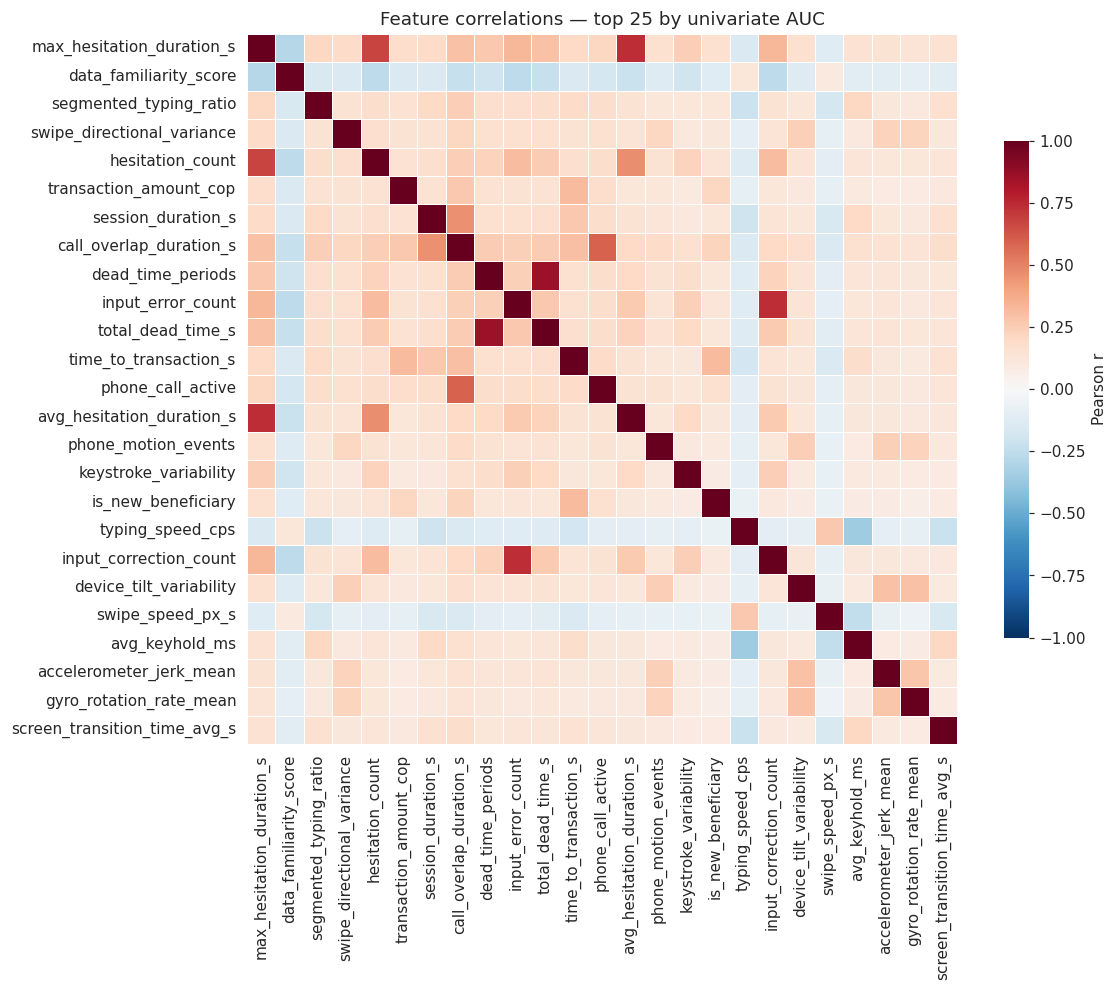

In [8]:
pares = vc.correlation_pairs(train, FEATS, umbral=0.70)
print("pares con |r| >= 0.70:", len(pares))
display(pares)
vc.write_csv(pares, vc.P.eda_correlations)

orden = sep.head(25).feature.tolist()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(train[orden].corr(), cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=ax,
            cbar_kws={"shrink": .7, "label": "Pearson r"})
ax.set_title("Feature correlations — top 25 by univariate AUC")
plt.tight_layout()
vc.save_figure(fig, vc.P.figure("fig_correlaciones.png"))
plt.show()

## 6. Perfil comportamental comparativo

,feature,mediana_legitima,mediana_vishing,norm_legitima,norm_vishing
0,segmented_typing_ratio,0.0764,0.2450,0.092888,0.297872
1,hesitation_count,1.0000,3.0000,0.066667,0.200000
2,data_familiarity_score,0.8194,0.6178,0.796787,0.568681
3,dead_time_periods,1.0000,2.0000,0.090909,0.181818
4,input_correction_count,1.0000,2.0000,0.050000,0.100000
5,typing_speed_cps,3.1880,2.5880,0.473844,0.377860
6,doodling_events,0.0000,1.0000,0.000000,0.142857
7,phone_motion_events,3.0000,5.0000,0.157895,0.263158
8,keystroke_variability,0.2306,0.3894,0.251502,0.424997


  escrito s3://poc-vishing/v2/06_results/eda/behavioral_profile.csv  (9 filas)
  figura -> s3://poc-vishing/v2/07_figures/fig05_perfil_comportamental.png


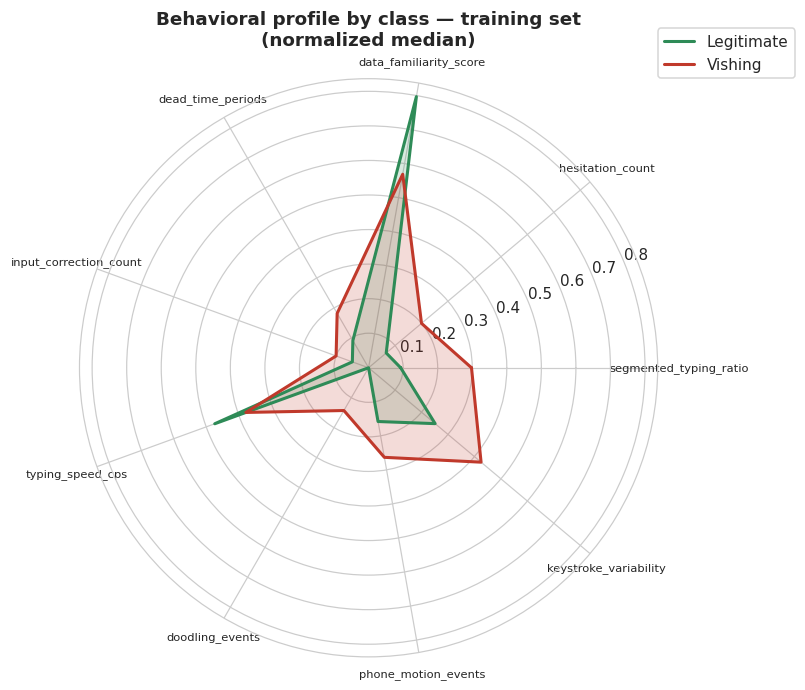

In [11]:
# Ejes del radar, en orden. Lista vacía => top-N comportamentales por |d|.
VARS_PERFIL = [
    'segmented_typing_ratio', 'hesitation_count', 'data_familiarity_score',
    'dead_time_periods', 'input_correction_count', 'typing_speed_cps',
    'doodling_events', 'phone_motion_events', 'keystroke_variability'
]
N_POR_DEFECTO_PERFIL = 9
# Familia de la que salen las variables por defecto: "behavioral", "context",
# "transaction", o None para elegir entre todas las del contrato.
FAMILIA_POR_DEFECTO = "behavioral"
# ─────────────────────────────────────────────────────────────────────────

if VARS_PERFIL:
    faltan = [f for f in VARS_PERFIL if f not in train.columns]
    assert not faltan, "variables inexistentes en train: %s" % faltan
    ejes = list(VARS_PERFIL)
else:
    universo = (contract["families"][FAMILIA_POR_DEFECTO]
                if FAMILIA_POR_DEFECTO else contract["features"])
    candidatas = [f for f in universo if f in FEATS]
    sub = sep[sep.feature.isin(candidatas) & ~sep.degenerada].copy()
    sub["abs_d"] = sub.cohens_d.abs()
    ejes = (sub.sort_values("abs_d", ascending=False)
               .head(N_POR_DEFECTO_PERFIL).feature.tolist())
    print("lista vacía -> por defecto, top %d de la familia '%s' por |d|"
          % (N_POR_DEFECTO_PERFIL, FAMILIA_POR_DEFECTO))

assert len(ejes) >= 3, "un radar necesita al menos 3 ejes"

perfil = vc.behavioral_profile(train, ejes)
display(perfil)
vc.write_csv(perfil, vc.P.eda_profile)

ang = np.linspace(0, 2 * np.pi, len(ejes), endpoint=False).tolist()
ang += ang[:1]
fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
for col, color, lab in [("norm_legitima", "#2e8b57", "Legitimate"),
                        ("norm_vishing", "#c0392b", "Vishing")]:
    v = perfil.set_index("feature").loc[ejes, col].tolist()
    v += v[:1]
    ax.plot(ang, v, color=color, lw=2, label=lab)
    ax.fill(ang, v, color=color, alpha=0.18)
ax.set_xticks(ang[:-1])
ax.set_xticklabels(ejes, fontsize=7.5)
ax.set_title("Behavioral profile by class — training set\n"
             "(normalized median)", fontweight="bold", pad=22)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
vc.save_figure(fig, vc.P.figure("fig05_perfil_comportamental.png"))
plt.show()

## 7. Análisis transaccional

sesiones con transacción: 36973 de 60134 (61.5%)
mediana del monto (solo sesiones con transacción):
  legítima: 249,229 COP
  vishing : 1,662,824 COP
  razón vishing/legítima: 6.67x

El manuscrito reporta 384.000 vs 136.000 COP sobre otra base.
En el v3 la brecha de medianas se limita a propósito: con la razón
de 10x que sugería el diseño original, esta sola variable superaba
el techo de separabilidad univariada. Ver
notas_metodologicas_generacion.md §5.2.
  figura -> s3://poc-vishing/v2/07_figures/fig_montos.png


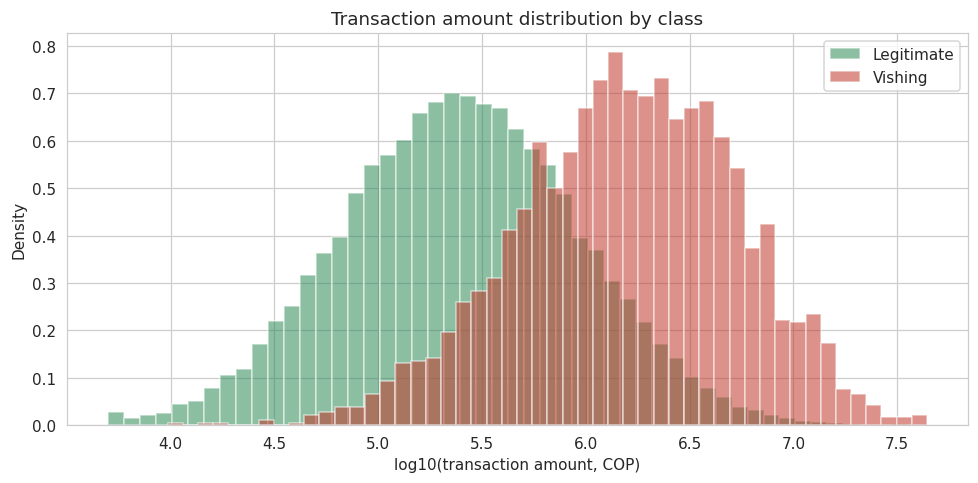

In [12]:
if "transaction_amount_cop" in train.columns:
    # Solo sesiones con transacción: el resto lleva el centinela -1, que NO es
    # un monto de cero y arruinaría la mediana si se incluyera.
    con_tx = train[train.get("transaction_attempted", 1) == 1]
    print("sesiones con transacción: %d de %d (%.1f%%)"
          % (len(con_tx), len(train), 100 * len(con_tx) / len(train)))
    med = con_tx.groupby(vc.TARGET).transaction_amount_cop.median()
    m0, m1 = float(med.get(0, np.nan)), float(med.get(1, np.nan))
    print("mediana del monto (solo sesiones con transacción):")
    print(f"  legítima: {m0:,.0f} COP")
    print(f"  vishing : {m1:,.0f} COP")
    if m0:
        print("  razón vishing/legítima: %.2fx" % (m1 / m0))
    print()
    print("El manuscrito reporta 384.000 vs 136.000 COP sobre otra base.")
    print("En el v3 la brecha de medianas se limita a propósito: con la razón")
    print("de 10x que sugería el diseño original, esta sola variable superaba")
    print("el techo de separabilidad univariada. Ver")
    print("notas_metodologicas_generacion.md §5.2.")

    fig, ax = plt.subplots(figsize=(9, 4.5))
    for v, c, lab in [(0, "#2e8b57", "Legitimate"), (1, "#c0392b", "Vishing")]:
        d = con_tx.loc[con_tx[vc.TARGET] == v, "transaction_amount_cop"]
        ax.hist(np.log10(d[d > 0]), bins=50, alpha=.55, density=True, color=c, label=lab)
    ax.set_xlabel("log10(transaction amount, COP)"); ax.set_ylabel("Density")
    ax.set_title("Transaction amount distribution by class"); ax.legend()
    plt.tight_layout()
    vc.save_figure(fig, vc.P.figure("fig_montos.png"))
    plt.show()

## 8. Análisis de componentes principales

varianza explicada: 5 comp = 33.0% | 10 comp = 47.4%
  figura -> s3://poc-vishing/v2/07_figures/fig_pca.png


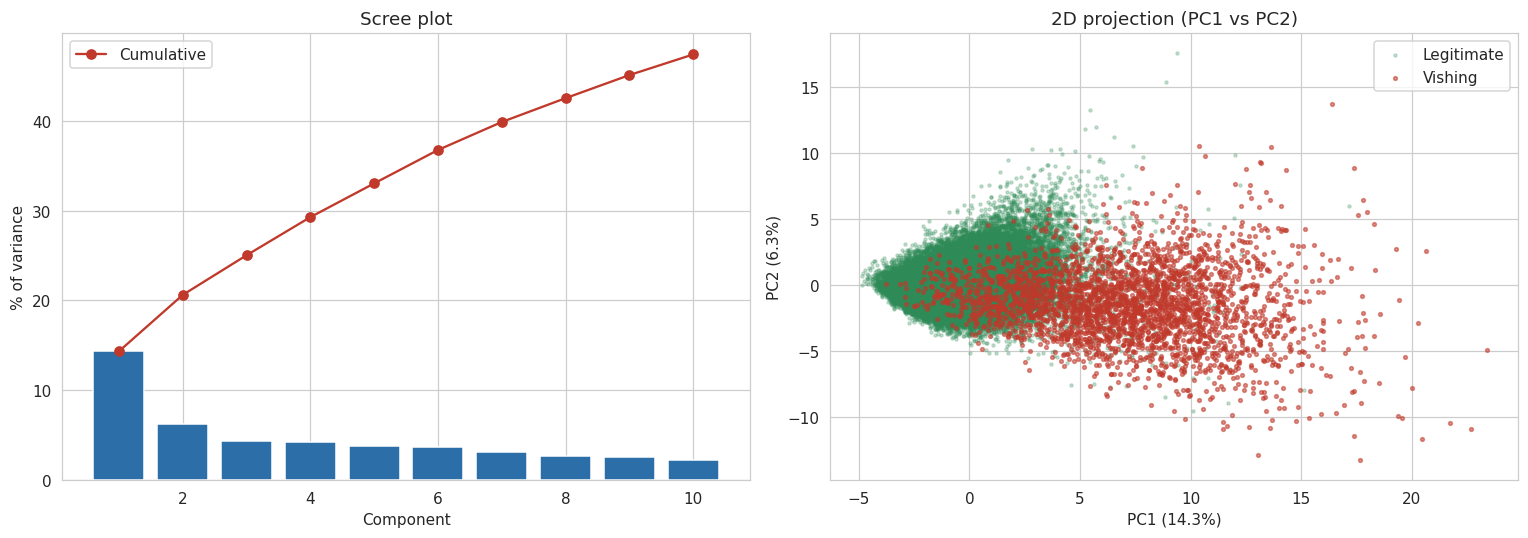

,PC1,PC2
max_hesitation_duration_s,0.272404,0.148667
hesitation_count,0.241688,0.145876
input_error_count,0.233216,0.196486
total_dead_time_s,0.230113,0.141120
call_overlap_duration_s,0.225182,-0.193965
avg_hesitation_duration_s,0.223053,0.170709
input_correction_count,0.220237,0.190617
dead_time_periods,0.216569,0.120076
data_familiarity_score,-0.183542,-0.028513
time_to_transaction_s,0.181525,-0.250480


  escrito s3://poc-vishing/v2/06_results/eda/pca_loadings.csv  (44 filas)


's3://poc-vishing/v2/06_results/eda/pca_loadings.csv'

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(train[FEATS].fillna(0))
pca = PCA(n_components=10, random_state=vc.SEED).fit(Xs)
Z = pca.transform(Xs)
var = pca.explained_variance_ratio_

print("varianza explicada: 5 comp = %.1f%% | 10 comp = %.1f%%"
      % (100 * var[:5].sum(), 100 * var.sum()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 11), var * 100, color="#2c6fa8")
axes[0].plot(range(1, 11), np.cumsum(var) * 100, "o-", color="#c0392b",
             label="Cumulative")
axes[0].set_xlabel("Component"); axes[0].set_ylabel("% of variance")
axes[0].set_title("Scree plot"); axes[0].legend()

m = train[vc.TARGET].values == 1
axes[1].scatter(Z[~m, 0], Z[~m, 1], s=4, alpha=.25, c="#2e8b57", label="Legitimate")
axes[1].scatter(Z[m, 0], Z[m, 1], s=6, alpha=.55, c="#c0392b", label="Vishing")
axes[1].set_xlabel("PC1 (%.1f%%)" % (100 * var[0]))
axes[1].set_ylabel("PC2 (%.1f%%)" % (100 * var[1]))
axes[1].set_title("2D projection (PC1 vs PC2)"); axes[1].legend()
plt.tight_layout()
vc.save_figure(fig, vc.P.figure("fig_pca.png"))
plt.show()

load = pd.DataFrame(pca.components_[:2].T, index=FEATS, columns=["PC1", "PC2"])
load["abs_PC1"] = load.PC1.abs()
display(load.sort_values("abs_PC1", ascending=False).head(12).drop(columns="abs_PC1"))
vc.write_csv(load.reset_index().rename(columns={"index": "feature"}), vc.P.eda_pca)

## 9. Valores atípicos y enriquecimiento de fraude

In [14]:
out = vc.outlier_enrichment(train, FEATS)
display(out.head(15))
print("\nUn enriquecimiento alto indica que la cola de esa variable concentra")
print("fraude: es candidata natural a regla de negocio complementaria al modelo.")
vc.write_csv(out, vc.P.eda_outliers)

,feature,n_outliers,tasa_vishing_outliers,tasa_vishing_global,enriquecimiento
0,dead_time_periods,303,0.8548,0.05,17.08
1,device_tilt_variability,591,0.6751,0.05,13.49
2,accelerometer_jerk_mean,592,0.6419,0.05,12.83
3,avg_interkey_latency_ms,1298,0.6002,0.05,11.99
4,gyro_rotation_rate_mean,406,0.5690,0.05,11.37
5,max_hesitation_duration_s,1760,0.5290,0.05,10.57
6,time_to_transaction_s,1472,0.5245,0.05,10.48
7,swipe_directional_variance,1079,0.4578,0.05,9.15
8,data_familiarity_score,1052,0.4563,0.05,9.12
9,avg_keyhold_ms,751,0.4288,0.05,8.57



Un enriquecimiento alto indica que la cola de esa variable concentra
fraude: es candidata natural a regla de negocio complementaria al modelo.
  escrito s3://poc-vishing/v2/06_results/eda/outlier_enrichment.csv  (33 filas)


's3://poc-vishing/v2/06_results/eda/outlier_enrichment.csv'

## 10. Importancia preliminar

Random forest con validación cruzada **dentro de train**, como estimación
temprana. No sustituye la importancia del modelo final (R8) ni la ablation por
familias (R6), que es la evidencia que el revisor pide.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                            random_state=vc.SEED, n_jobs=-1, class_weight="balanced")
cv = StratifiedKFold(5, shuffle=True, random_state=vc.SEED)
sc = cross_val_score(rf, train[FEATS].fillna(0), train[vc.TARGET],
                     cv=cv, scoring="average_precision", n_jobs=-1)
print("PR-AUC en validación cruzada (dentro de train): %.4f +/- %.4f"
      % (sc.mean(), sc.std()))
print("(el manuscrito cita ROC-AUC ~0.88 de un bosque rápido sobre otra base)")

rf.fit(train[FEATS].fillna(0), train[vc.TARGET])
imp = (pd.DataFrame({"feature": FEATS, "importancia": rf.feature_importances_})
       .sort_values("importancia", ascending=False).reset_index(drop=True))
display(imp.head(15))

PR-AUC en validación cruzada (dentro de train): 0.8164 +/- 0.0155
(el manuscrito cita ROC-AUC ~0.88 de un bosque rápido sobre otra base)


,feature,importancia
0,call_overlap_duration_s,0.137043
1,phone_call_active,0.087932
2,max_hesitation_duration_s,0.086855
3,transaction_amount_cop,0.072228
4,data_familiarity_score,0.067336
5,segmented_typing_ratio,0.066515
6,swipe_directional_variance,0.056110
7,is_new_beneficiary,0.041618
8,time_to_transaction_s,0.040680
9,dead_time_periods,0.030936


In [16]:
resumen = {
    "base_de_calculo": {
        "particion": "train", "dataset": vc.RAW_FILENAME,
        "esquema": vc.DATASET_VERSION,
        "sesiones": int(len(train)),
        "clientes": int(train[vc.GROUP_COL].nunique()),
        "tasa_vishing": float(train[vc.TARGET].mean()),
        "n_features": len(FEATS), "policy": contract["policy"],
    },
    "separabilidad": {
        "efectos": sep.efecto.value_counts().to_dict(),
        "significativas_p001": int((sep.p_mannwhitney < 0.001).sum()),
        "auc_max": float(sep.auc_dir.max()),
        "techo_declarado": TECHO_AUC,
        "features_auc_sobre_080": int((sep.auc_dir > 0.80).sum()),
        "features_auc_sobre_techo": int((sep.auc_dir > TECHO_AUC).sum()),
        "top5_auc": sep.head(5)[["feature", "auc_dir"]].to_dict("records"),
    },
    "binarias_top": binarias.head(6)[
        ["feature", "odds_ratio", "or_ic95_lo", "or_ic95_hi", "p"]].to_dict("records"),
    "pca": {"var_5": float(var[:5].sum()), "var_10": float(var.sum())},
    "rf_cv_pr_auc": {"media": float(sc.mean()), "std": float(sc.std())},
    "correlaciones_altas": int(len(pares)),
}
vc.write_json(resumen, vc.P.eda_summary)
print("R1 completo. Continuar con R2.")

  escrito s3://poc-vishing/v2/06_results/eda/summary.json
R1 completo. Continuar con R2.
